# <center><strong>Airbnb Price Prediction</strong></center>
-------------------

#### **By Mohamed Jamyl and Hasna el khachabi**

http://linkedin.com/in/mohamed-jamyl

https://www.linkedin.com/in/hasna-el-khachabi

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

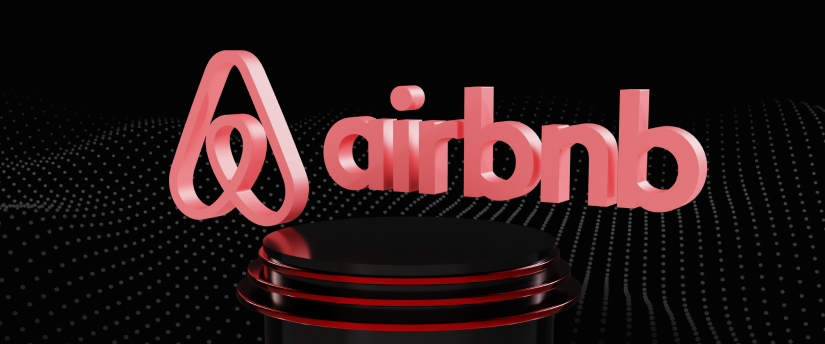

In [2]:
from IPython.display import Image
Image(filename='airbnb-logo.jpg') 

--------------------------------
--------------------------------
## **Import Libraries**
--------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pickle 

---------------------------------------
---------------------------------------

## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [270]:
df = pd.read_csv('Listings.csv',encoding='latin1')

C:\Users\RPC\AppData\Local\Temp\ipykernel_9932\1360166263.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Listings.csv',encoding='latin1')


In [271]:
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,12/3/2011,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,11/29/2013,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,7/31/2014,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,12/17/2013,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Vaugirard,NaN,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,12/14/2014,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Passy,NaN,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [272]:
df.shape

(279712, 33)

In [273]:
df['district'].value_counts()

district
Manhattan        16553
Brooklyn         14474
Queens            4704
Bronx              992
Staten Island      289
Name: count, dtype: int64

In [274]:
df.loc[df['city']=='Paris',['city','district']]

,city,district
0,Paris,NaN
1,Paris,NaN
2,Paris,NaN
3,Paris,NaN
4,Paris,NaN
...,...,...
279707,Paris,NaN
279708,Paris,NaN
279709,Paris,NaN
279710,Paris,NaN


In [275]:
df['city'].value_counts()

city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087
Name: count, dtype: int64

In [276]:
df.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [278]:
df.isnull().sum()

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

In [279]:
df=df.drop(['host_id','listing_id', 'name', 'host_response_rate', 'host_acceptance_rate','district','host_has_profile_pic',
           'maximum_nights','host_response_time','latitude', 'longitude'], axis = 1)

In [280]:
df.columns

Index(['host_since', 'host_location', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'neighbourhood',
       'city', 'property_type', 'room_type', 'accommodates', 'bedrooms',
       'amenities', 'price', 'minimum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [281]:
df.duplicated().sum()

np.int64(1783)

In [282]:
df.drop_duplicates(inplace=True)

-----------------------------------------

In [283]:
df['price'].describe().T

count    277929.000000
mean        607.117487
std        3446.782242
min           0.000000
25%          75.000000
50%         150.000000
75%         466.000000
max      625216.000000
Name: price, dtype: float64

In [284]:
df.loc[df['price']<=450].shape

(207720, 22)

In [285]:
df.select_dtypes(include='object').describe()

,host_since,host_location,host_is_superhost,host_identity_verified,neighbourhood,city,property_type,room_type,amenities,instant_bookable
count,277766,277099,277766,277766,277929,277929,277929,277929,277929,277929
unique,4240,7159,2,2,660,10,144,4,245003,2
top,9/2/2019,"Paris, Ile-de-France, France",f,t,I Centro Storico,Paris,Entire apartment,Entire place,"[""Long term stays allowed""]",f
freq,710,47743,227811,200009,14779,64610,138591,181429,1380,163515


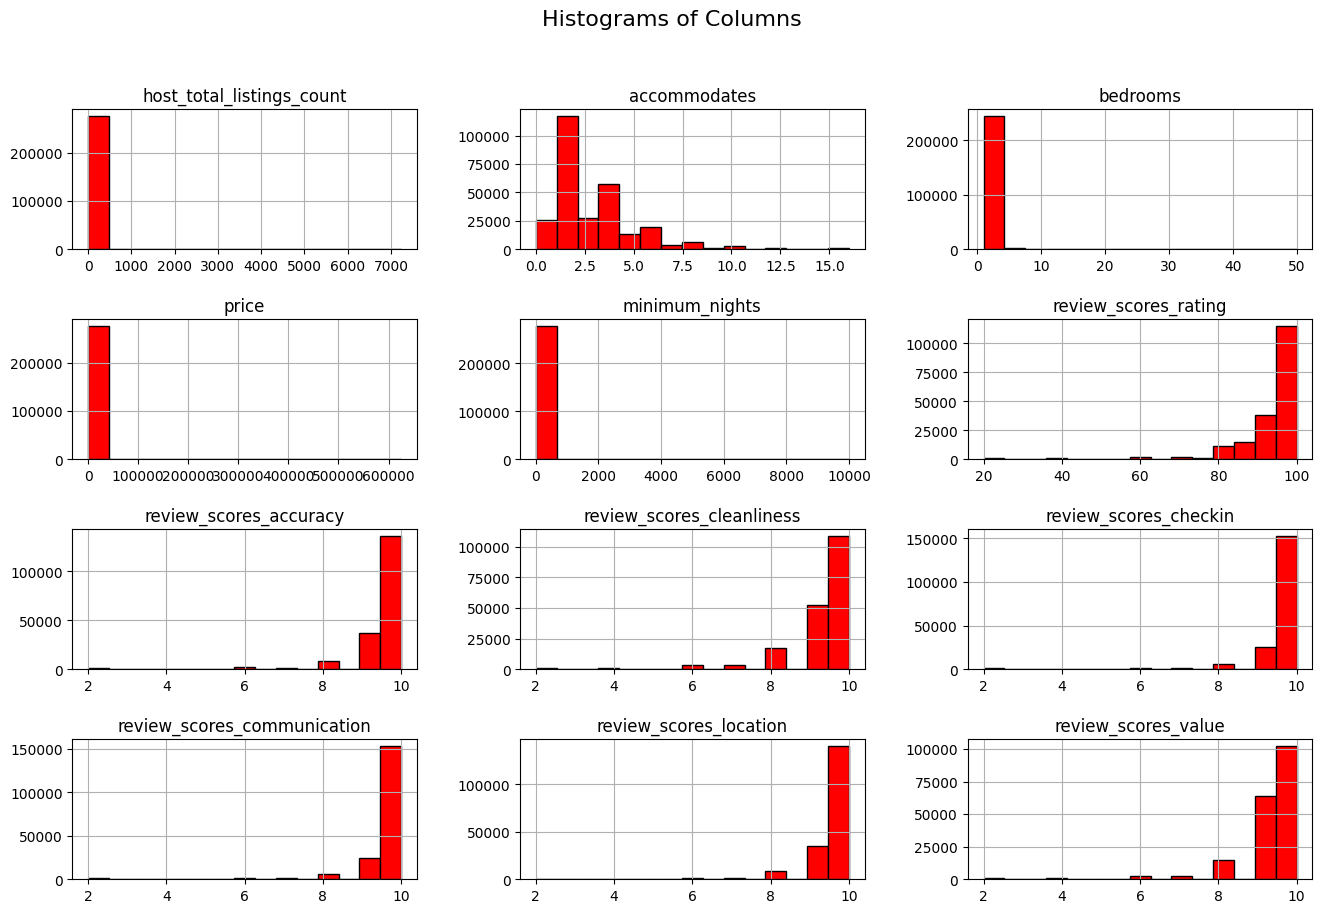

In [286]:
df.hist(bins=15, figsize=(16, 10), color='red', edgecolor='black')

#Set titles and labels for each subplot
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  # Add space between plots
plt.show()

---------------------------------------

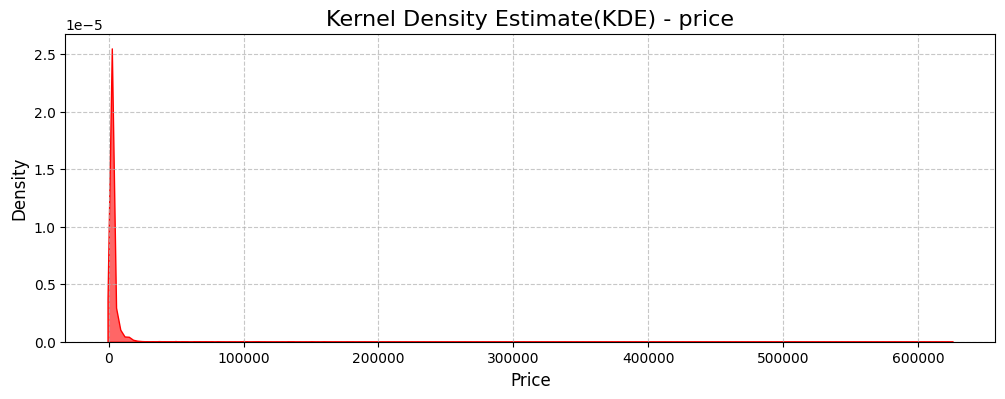

In [287]:
plt.figure(figsize=(12,	4))
sns.kdeplot(df['price'], fill=True,	color='red', alpha=0.6)
plt.title('Kernel Density Estimate(KDE) - price',	fontsize=16)
plt.xlabel('Price',	fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

-----------------------------

### **Checking Correlation between the features**

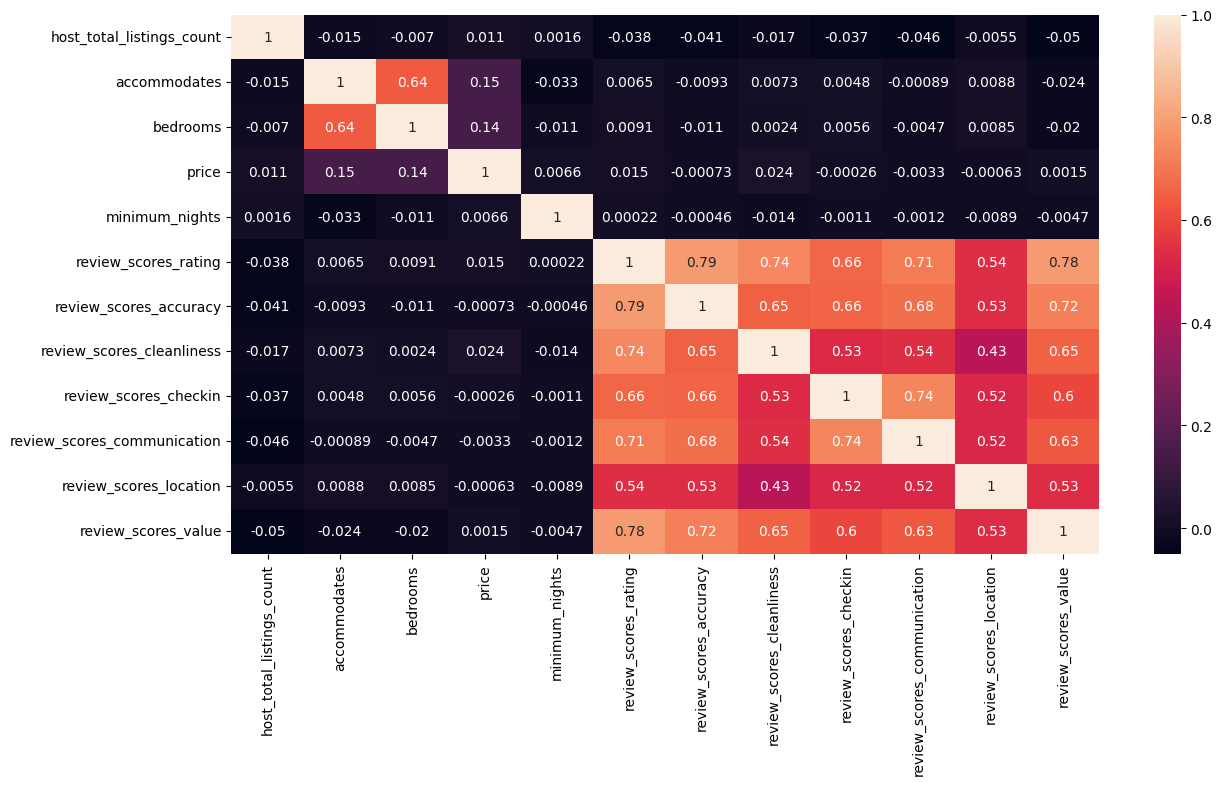

In [288]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

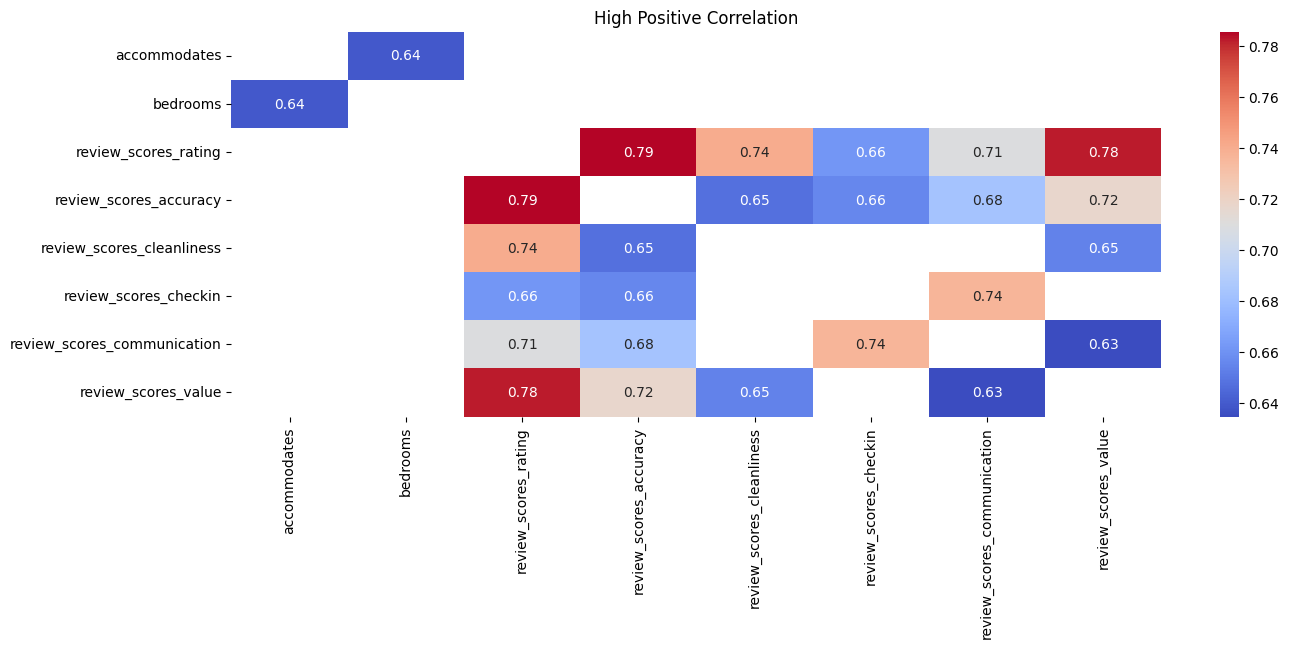

In [289]:
# # function to extract high positive correlated columns
def get_high_corr(df, threshold):
     corr = df.select_dtypes('number').corr()
     high_corr = corr[(corr >= threshold) & (corr != 1.000)]
     high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
     return high_corr

# # get high positive correlated columns
high_corr = get_high_corr(df, 0.6)

 # plot high positive correlated columns
plt.figure(figsize=(15, 5))
plt.plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plt.plot.set_title('High Positive Correlation')
plt.show()

In [290]:
 # plot scatter plot for high correlated columns
def scatter(df, x, y, title):
     plt.figure(figsize=(14, 4))
     plt.ax = sns.scatterplot(x=x, y=y, data=df)
     plt.ax.set_title(title)
     plt.show()

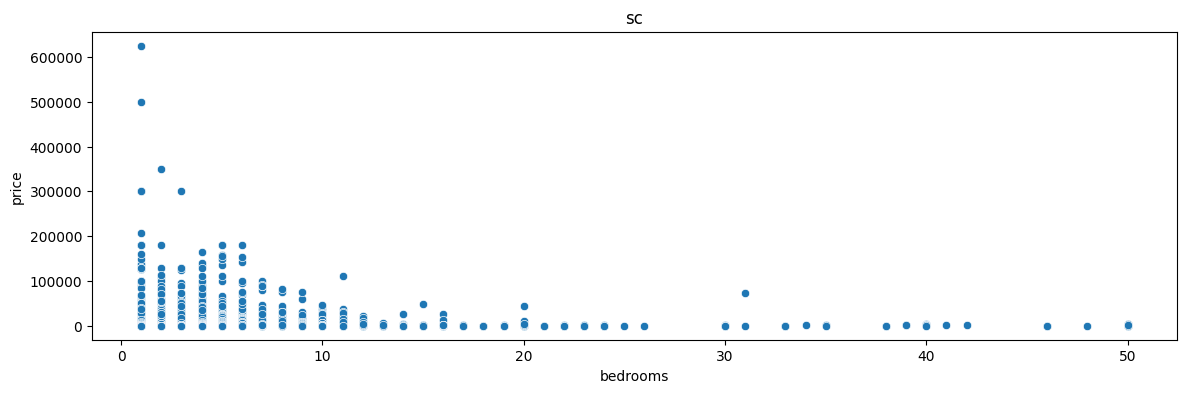

In [291]:
scatter(df, 'bedrooms', 'price', 'sc')

------------------
## **Detect Outliers**
-----------------

In [292]:
df['price'].describe()

count    277929.000000
mean        607.117487
std        3446.782242
min           0.000000
25%          75.000000
50%         150.000000
75%         466.000000
max      625216.000000
Name: price, dtype: float64

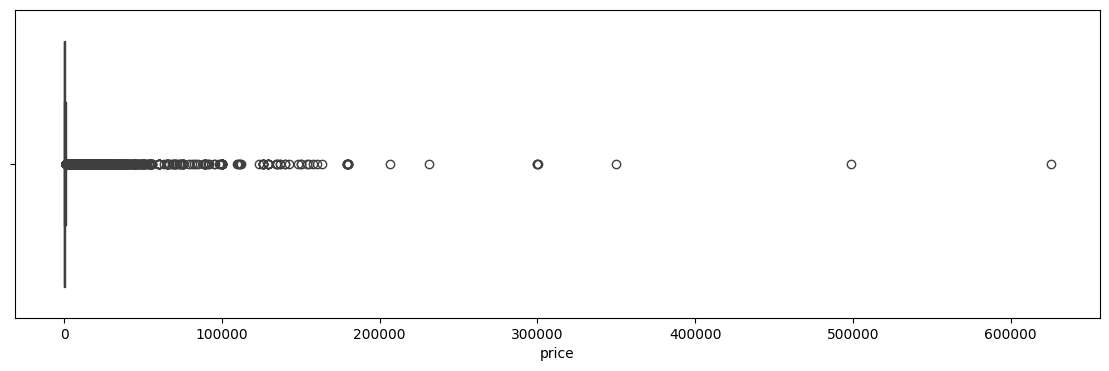

In [293]:
plt.fig, axes = plt.subplots(nrows=1,ncols=1)
plt.fig.set_size_inches(14, 4)
sns.boxplot(data=df,x="price",orient="o",ax=axes)
plt.show()

------------------------------------------
## **Feature Extraction**
------------------------------------------

In [294]:
df.columns

Index(['host_since', 'host_location', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'neighbourhood',
       'city', 'property_type', 'room_type', 'accommodates', 'bedrooms',
       'amenities', 'price', 'minimum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [295]:
df['host_since']

0          12/3/2011
1         11/29/2013
2          7/31/2014
3         12/17/2013
4         12/14/2014
             ...    
279707     4/13/2015
279708    11/27/2013
279709     4/27/2012
279710     7/16/2015
279711     6/17/2013
Name: host_since, Length: 277929, dtype: object

In [296]:
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['host_year'] = df['host_since'].dt.year.fillna(df['host_since'].dt.year.median())
df.drop(columns=['host_since'], inplace=True)

In [297]:
df['host_year']=df['host_year'].astype(int)

In [298]:
df['host_year']

0         2011
1         2013
2         2014
3         2013
4         2014
          ... 
279707    2015
279708    2013
279709    2012
279710    2015
279711    2013
Name: host_year, Length: 277929, dtype: int64

In [299]:
key_amenities = [
    'Heating',
    'Kitchen',
    'Wifi',
    'Essentials',
    'Washer',
    'Long term stays allowed',
    'Smoke alarm',
    'Hair dryer',
    'Iron',
    'Dedicated workspace',
    'Hangers',
    'Hot water',
    'TV',
    'Cable TV',
    'Refrigerator',
    'Oven',
    'Stove',
    'Cooking basics',
    'Dishes and silverware',
    'Coffee maker',
    'Dishwasher',
    'Microwave',
    'Carbon monoxide alarm',
    'Fire extinguisher',
    'First aid kit',
    'Shampoo',
    'Elevator',
    'Paid parking off premises',
    'Free street parking',
    'Bathtub'
]

for amenity in key_amenities:
    df[amenity] = df['amenities'].apply(lambda x: 1 if amenity in str(x) else 0)

In [300]:
df.columns

Index(['host_location', 'host_is_superhost', 'host_total_listings_count',
       'host_identity_verified', 'neighbourhood', 'city', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'host_year', 'Heating',
       'Kitchen', 'Wifi', 'Essentials', 'Washer', 'Long term stays allowed',
       'Smoke alarm', 'Hair dryer', 'Iron', 'Dedicated workspace', 'Hangers',
       'Hot water', 'TV', 'Cable TV', 'Refrigerator', 'Oven', 'Stove',
       'Cooking basics', 'Dishes and silverware', 'Coffee maker', 'Dishwasher',
       'Microwave', 'Carbon monoxide alarm', 'Fire extinguisher',
       'First aid kit', 'Shampoo', 'Elevator', 'Paid parking off premises',
       'Free street parking', 'Bathtub'],
      dtype='obje

In [301]:
df = df.loc[df['price']<=250]

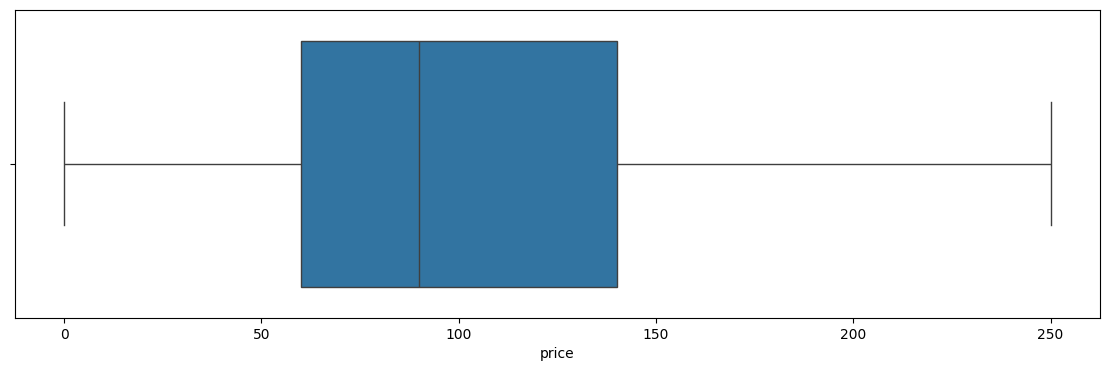

In [302]:
plt.fig, axes = plt.subplots(nrows=1,ncols=1)
plt.fig.set_size_inches(14, 4)
sns.boxplot(data=df,x="price",orient="o",ax=axes)
plt.show()

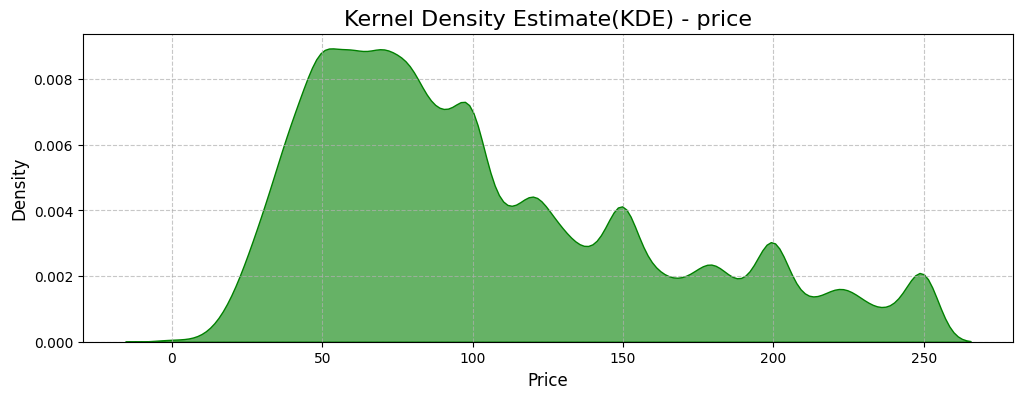

In [303]:
plt.figure(figsize=(12,	4))
sns.kdeplot(df['price'], fill=True,	color='green', alpha=0.6)
plt.title('Kernel Density Estimate(KDE) - price',	fontsize=16)
plt.xlabel('Price',	fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [304]:
df.shape

(176275, 52)

In [305]:
df['property_type']

0         Entire apartment
1         Entire apartment
2         Entire apartment
3         Entire apartment
4         Entire apartment
                ...       
279707    Entire apartment
279708    Entire apartment
279709    Entire apartment
279710    Entire apartment
279711    Entire apartment
Name: property_type, Length: 176275, dtype: object

In [306]:
df.isnull().sum()

host_location                    456
host_is_superhost                114
host_total_listings_count        114
host_identity_verified           114
neighbourhood                      0
city                               0
property_type                      0
room_type                          0
accommodates                       0
bedrooms                       22463
amenities                          0
price                              0
minimum_nights                     0
review_scores_rating           50282
review_scores_accuracy         50485
review_scores_cleanliness      50448
review_scores_checkin          50526
review_scores_communication    50462
review_scores_location         50528
review_scores_value            50533
instant_bookable                   0
host_year                          0
Heating                            0
Kitchen                            0
Wifi                               0
Essentials                         0
Washer                             0
L

In [307]:
df.columns

Index(['host_location', 'host_is_superhost', 'host_total_listings_count',
       'host_identity_verified', 'neighbourhood', 'city', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'host_year', 'Heating',
       'Kitchen', 'Wifi', 'Essentials', 'Washer', 'Long term stays allowed',
       'Smoke alarm', 'Hair dryer', 'Iron', 'Dedicated workspace', 'Hangers',
       'Hot water', 'TV', 'Cable TV', 'Refrigerator', 'Oven', 'Stove',
       'Cooking basics', 'Dishes and silverware', 'Coffee maker', 'Dishwasher',
       'Microwave', 'Carbon monoxide alarm', 'Fire extinguisher',
       'First aid kit', 'Shampoo', 'Elevator', 'Paid parking off premises',
       'Free street parking', 'Bathtub'],
      dtype='obje

In [308]:
df= df.drop(['host_location','amenities','neighbourhood'], axis=1)

In [309]:
property_categories = {
    "ENTIRE_SPACE": [
        'Entire apartment', 'Entire loft', 'Entire house', 'Entire condominium',
        'Entire townhouse', 'Entire serviced apartment', 'Entire bungalow',
        'Entire villa', 'Entire guest suite', 'Entire cottage',
        'Entire guesthouse', 'Entire chalet', 'Entire bed and breakfast',
        'Entire cabin', 'Entire tent', 'Entire hostel',
        'Entire home/apt', 'Entire resort', 'Entire dorm',
        'Entire vacation home', 'Entire floor', 'Entire in-law'
    ],
    "PRIVATE_ROOM": [
        'Private room in apartment', 'Private room in townhouse',
        'Private room in house', 'Private room in condominium',
        'Private room in guesthouse', 'Private room in serviced apartment',
        'Private room in villa', 'Private room in guest suite',
        'Private room in hostel', 'Private room in loft',
        'Private room in cabin', 'Private room in chalet',
        'Private room in cottage', 'Private room in yurt',
        'Private room in hut', 'Private room in resort',
        'Private room in bungalow', 'Private room in houseboat',
        'Private room in farm stay', 'Private room in pousada',
        'Private room in dorm', 'Private room in pension',
        'Private room in tipi', 'Private room in boat',
        'Private room in treehouse', 'Private room in cave',
        'Private room in lighthouse', 'Private room in barn',
        'Private room in bus', 'Private room in minsu',
        'Private room', 'Private room in island', 'Private room in dome house',
        'Private room in earth house', 'Private room in kezhan',
        'Private room in in-law'
    ],
"SHARED_ROOM": [
        'Shared room in apartment', 'Shared room in condominium',
        'Shared room in house', 'Shared room in townhouse',
        'Shared room in guesthouse', 'Shared room in chalet',
        'Shared room in boutique hotel', 'Shared room in bed and breakfast',
        'Shared room in hostel', 'Shared room in dorm',
        'Shared room in yurt', 'Shared room in boat',
        'Shared room in tiny house', 'Shared room in train',
        'Shared room', 'Shared room in island', 'Shared room in tent',
        'Shared room in cave', 'Shared room in tipi', 'Shared room in hut',
        'Shared room in cabin', 'Shared room in farm stay',
        'Shared room in resort', 'Shared room in bungalow',
        'Shared room in serviced apartment'
    ],

    "SPECIAL_UNIQUE": [
        'Treehouse', 'Yurt', 'Camper/RV', 'Boat', 'Houseboat',
        'Farm stay', 'Barn', 'Campsite', 'Tiny house', 'Castle',
        'Island', 'Dome house', 'Lighthouse', 'Earth house',
        'Bus', 'Igloo', 'Train', 'Tent', 'Windmill',
        'Cave', 'Pension', 'Holiday park'
    ],

    "HOTEL_STYLE": [
        'Room in aparthotel', 'Room in serviced apartment', 'Room in hotel',
        'Room in boutique hotel', 'Room in bed and breakfast',
        'Room in resort', 'Room in hostel', 'Room in nature lodge',
        'Room in guesthouse', 'Room in pension', 'Room in casa particular',
        'Room in heritage hotel', 'Holiday park'
    ],
"CAMPING_OUTDOOR": [
        'Campsite', 'Tent', 'Tipi', 'Yurt', 'Treehouse', 'Igloo'
    ]
}


def categorize_property(ptype):
    for category, items in property_categories.items():
        if ptype in items:
            return category
    return "OTHER"


df['property_category'] = df['property_type'].apply(categorize_property)

In [310]:
df=df.drop('property_type',axis=1)

In [311]:
num_col = ['bedrooms','review_scores_rating','review_scores_accuracy', 
            'review_scores_cleanliness', 'review_scores_checkin', 
            'review_scores_communication', 'review_scores_location', 
            'review_scores_value']

for col in num_col:
    df[col].fillna(df[col].median(), inplace=True) 

C:\Users\RPC\AppData\Local\Temp\ipykernel_9932\450965017.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\RPC\AppData\Local\Temp\ipykernel_9932\450965017.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [312]:
df = df.dropna()

In [313]:
df.isnull().sum()

host_is_superhost              0
host_total_listings_count      0
host_identity_verified         0
city                           0
room_type                      0
accommodates                   0
bedrooms                       0
price                          0
minimum_nights                 0
review_scores_rating           0
review_scores_accuracy         0
review_scores_cleanliness      0
review_scores_checkin          0
review_scores_communication    0
review_scores_location         0
review_scores_value            0
instant_bookable               0
host_year                      0
Heating                        0
Kitchen                        0
Wifi                           0
Essentials                     0
Washer                         0
Long term stays allowed        0
Smoke alarm                    0
Hair dryer                     0
Iron                           0
Dedicated workspace            0
Hangers                        0
Hot water                      0
TV        

In [314]:
df['price per bed'] = df['price'] / df['bedrooms']
df['price per bed'].head()

0     53.0
1    120.0
2     89.0
3     58.0
4     60.0
Name: price per bed, dtype: float64

In [315]:
df = df.iloc[:176000,:]

---------------------
## **Transform data**
---------------------

In [316]:
data_obj = df.select_dtypes('object')
data_non_obj = df.select_dtypes('number')

In [317]:
data_obj

,host_is_superhost,host_identity_verified,city,room_type,instant_bookable,property_category
0,f,f,Paris,Entire place,f,ENTIRE_SPACE
1,f,t,Paris,Entire place,f,ENTIRE_SPACE
2,f,f,Paris,Entire place,f,ENTIRE_SPACE
3,f,t,Paris,Entire place,f,ENTIRE_SPACE
4,f,f,Paris,Entire place,f,ENTIRE_SPACE
...,...,...,...,...,...,...
279546,f,t,Paris,Entire place,f,ENTIRE_SPACE
279547,f,t,Paris,Entire place,f,ENTIRE_SPACE
279548,f,t,Paris,Entire place,f,ENTIRE_SPACE
279549,f,t,Paris,Entire place,f,ENTIRE_SPACE


In [318]:
df_object_for_ohe = data_obj[['instant_bookable','host_identity_verified','host_is_superhost']].columns

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = ohe.fit_transform(data_obj[df_object_for_ohe])
one_hot_columns = ohe.get_feature_names_out(df_object_for_ohe)
df_ohe = pd.DataFrame(one_hot_encoded, columns=one_hot_columns, index=df.index)
df_for_ohe = data_obj.drop(columns=df_object_for_ohe).join(df_ohe)

In [319]:
#with open('One_Hot_Encoder.pkl', 'wb') as f:
  #   pickle.dump(ohe, f)

In [320]:
df_for_ohe.columns

Index(['city', 'room_type', 'property_category', 'instant_bookable_f',
       'instant_bookable_t', 'host_identity_verified_f',
       'host_identity_verified_t', 'host_is_superhost_f',
       'host_is_superhost_t'],
      dtype='object')

In [321]:
categorical_cols = df_for_ohe[['city','room_type','property_category']]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_for_ohe[col] = le.fit_transform(df_for_ohe[col].astype(str))
    label_encoders[col] = le

In [322]:
mapping = {category : index for index, category in enumerate(label_encoders['property_category'].classes_)}
print(mapping)

{'CAMPING_OUTDOOR': 0, 'ENTIRE_SPACE': 1, 'HOTEL_STYLE': 2, 'OTHER': 3, 'PRIVATE_ROOM': 4, 'SHARED_ROOM': 5, 'SPECIAL_UNIQUE': 6}


In [323]:
#with open('label_encoders.pkl','wb') as f:
 #    pickle.dump(le, f)

In [324]:
df = pd.concat([data_non_obj,df_for_ohe],axis=1)

In [325]:
df

,host_total_listings_count,accommodates,bedrooms,price,minimum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_year,Heating,Kitchen,Wifi,Essentials,Washer,Long term stays allowed,Smoke alarm,Hair dryer,Iron,Dedicated workspace,Hangers,Hot water,TV,Cable TV,Refrigerator,Oven,Stove,Cooking basics,Dishes and silverware,Coffee maker,Dishwasher,Microwave,Carbon monoxide alarm,Fire extinguisher,First aid kit,Shampoo,Elevator,Paid parking off premises,Free street parking,Bathtub,price per bed,city,room_type,property_category,instant_bookable_f,instant_bookable_t,host_identity_verified_f,host_identity_verified_t,host_is_superhost_f,host_is_superhost_t
0,1.0,2,1.0,53,2,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2011,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,53.0,6,0,1,1.0,0.0,1.0,0.0,1.0,0.0
1,1.0,2,1.0,120,2,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2013,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,120.0,6,0,1,1.0,0.0,0.0,1.0,1.0,0.0
2,1.0,2,1.0,89,2,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2014,1,1,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89.0,6,0,1,1.0,0.0,1.0,0.0,1.0,0.0
3,1.0,2,1.0,58,2,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2013,1,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,58.0,6,0,1,1.0,0.0,0.0,1.0,1.0,0.0
4,1.0,2,1.0,60,2,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2014,1,1,1,1,1,1,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,60.0,6,0,1,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279546,1.0,2,1.0,59,2,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2012,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,59.0,6,0,1,1.0,0.0,0.0,1.0,1.0,0.0
279547,1.0,2,1.0,50,3,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2015,1,1,1,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,50.0,6,0,1,1.0,0.0,0.0,1.0,1.0,0.0
279548,1.0,2,1.0,55,4,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2013,1,1,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,55.0,6,0,1,1.0,0.0,0.0,1.0,1.0,0.0
279549,1.0,2,1.0,68,2,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2015,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68.0,6,0,1,1.0,0.0,0.0,1.0,1.0,0.0


-----------------------------
## **Creating Model**
------------------------
### **Spliting Data to train and test**
-----------------------

In [ ]:
x = df.drop('price',axis=1)
y = df['price']

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [329]:
print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_test : {x_test.shape}')
print(f'shape of x_test : {x_val.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_test : {y_test.shape}')
print(f'shape of y_test : {y_val.shape}')

shape of x_train : (113377, 52)
shape of x_test : (24296, 52)
shape of x_test : (24295, 52)
-------------------------------
shape of y_train : (113377,)
shape of y_test : (24296,)
shape of y_test : (24295,)


------------------------

In [ ]:
r_2=[]
rmse=[]
mae=[]

def Regression_func(model):
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    R2 = r2_score(y_test, pred)
    RMSE = sqrt(mean_squared_error(y_test, pred))
    MAE = mean_absolute_error(y_test, pred)

    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

In [ ]:
GradientBoostingRegressor_model = GradientBoostingRegressor()
XGBRegressor_model	= XGBRegressor()
RandomForestRegressor_model	= RandomForestRegressor()

In [ ]:
Regression_func(GradientBoostingRegressor_model)

In [ ]:
Regression_func(XGBRegressor_model)

In [ ]:
Regression_func(RandomForestRegressor_model)

In [ ]:
Algorithms	=	['GradientBoostingRegressor', 'XGBRegressor','RandomForestRegressor']

In [ ]:
result=pd.DataFrame({'Algorithms':Algorithms,'R2':r_2,'rmse':rmse,'mae':mae})
result

,Algorithms,R2,rmse,mae
0,GradientBoostingRegressor,0.998896,1.926383,0.986479
1,XGBRegressor,0.999576,1.194423,0.312994
2,RandomForestRegressor,0.999805,0.810526,0.026146


--------------------------

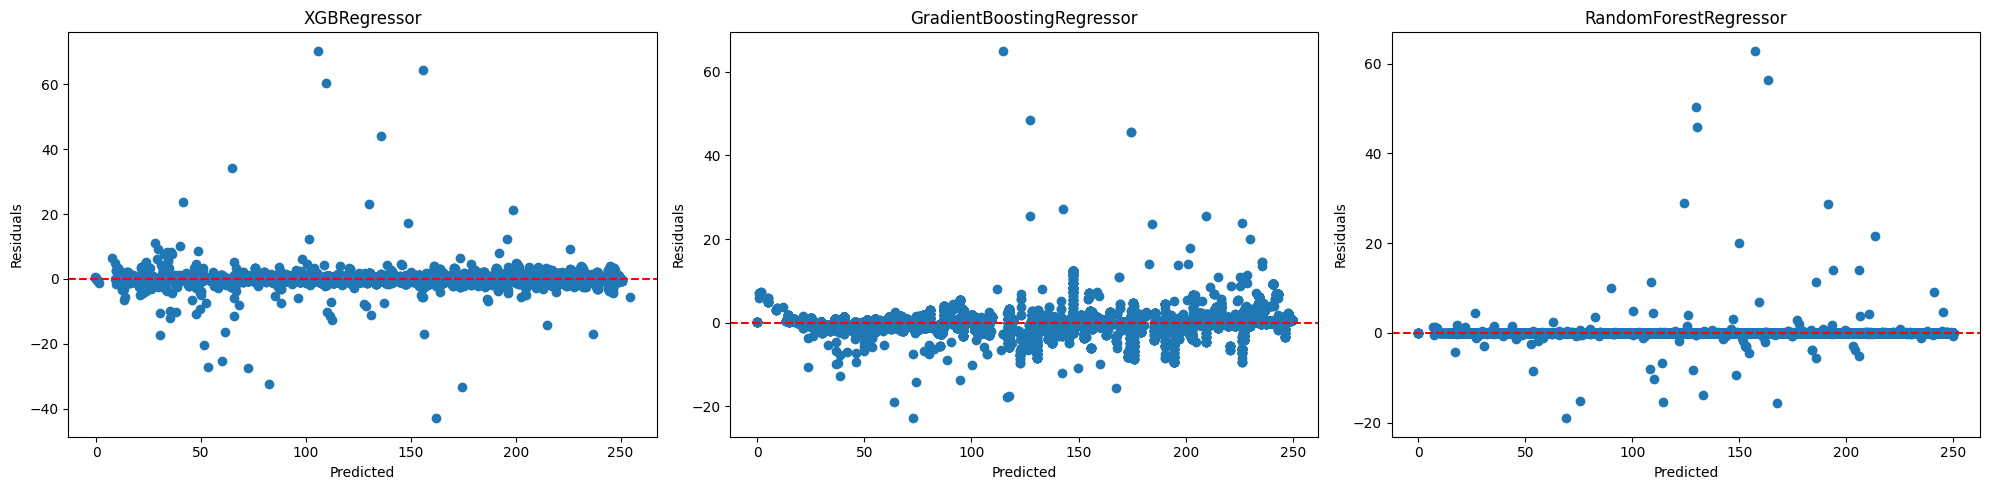

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))  

residuals_xgb = y_test - XGBRegressor_model.predict(x_test)
axes[0].scatter(XGBRegressor_model.predict(x_test), residuals_xgb)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("XGBRegressor")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_lr = y_test - GradientBoostingRegressor_model.predict(x_test)
axes[1].scatter(GradientBoostingRegressor_model.predict(x_test), residuals_lr)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("GradientBoostingRegressor")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

residuals_dt = y_test - RandomForestRegressor_model.predict(x_test)
axes[2].scatter(RandomForestRegressor_model.predict(x_test), residuals_dt)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("RandomForestRegressor")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [ ]:
#with open('XGBRegressor_model.pkl' , 'wb') as f :
 #  pickle.dump(XGBRegressor_model, f)

In [ ]:
#with open('GradientBoostingRegressor_model.pkl' , 'wb') as f :
  #  pickle.dump(GradientBoostingRegressor_model, f)

In [ ]:
#with open('RandomForestRegressor_model.pkl' , 'wb') as f :
 #   pickle.dump(RandomForestRegressor_model, f)

-----------------------
### **Testing Model**
----------------------

In [372]:
with open('XGBRegressor_model.pkl','rb') as f : 
    XGBRegressor_model = pickle.load(f)

In [373]:
y_predict = XGBRegressor_model.predict(x_test)

In [374]:
Importance = XGBRegressor_model.feature_importances_
indices = np.argsort(Importance)[::-1]

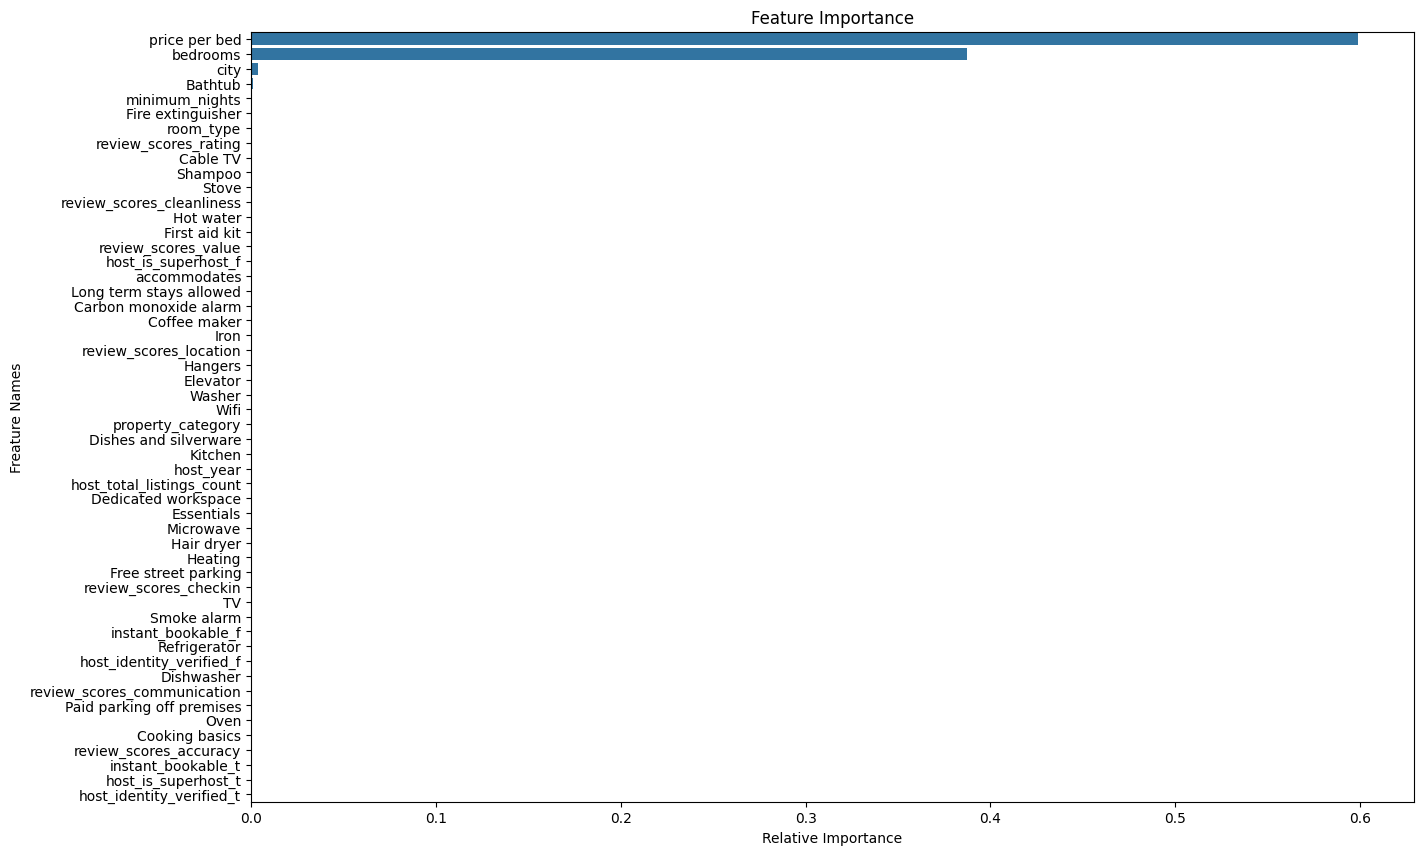

In [375]:
plt.figure(figsize=(15, 10))
sns.barplot(x = Importance[indices], y = x.columns[indices])
plt.title('Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Freature Names')
plt.show()

In [376]:
data_test = pd.read_csv('data_for_test.csv')
data_test.head()

,host_is_superhost,host_total_listings_count,host_identity_verified,city,room_type,accommodates,bedrooms,price,minimum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,host_year,Heating,Kitchen,Wifi,Essentials,Washer,Long term stays allowed,Smoke alarm,Hair dryer,Iron,Dedicated workspace,Hangers,Hot water,TV,Cable TV,Refrigerator,Oven,Stove,Cooking basics,Dishes and silverware,Coffee maker,Dishwasher,Microwave,Carbon monoxide alarm,Fire extinguisher,First aid kit,Shampoo,Elevator,Paid parking off premises,Free street parking,Bathtub,property_category,price per bed
0,f,1.0,t,Paris,Entire place,2,1.0,9,5,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,2013,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,ENTIRE_SPACE,9.0
1,f,1.0,t,Paris,Entire place,2,1.0,54,2,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,2015,1,1,1,1,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,ENTIRE_SPACE,54.0
2,f,1.0,t,Paris,Entire place,2,1.0,89,1,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,2013,1,1,1,1,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,ENTIRE_SPACE,89.0
3,f,1.0,t,Paris,Entire place,2,1.0,60,14,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,2015,1,1,1,1,1,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,ENTIRE_SPACE,60.0
4,f,1.0,t,Paris,Entire place,2,1.0,146,4,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,2013,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,1,1,0,1,0,0,0,0,1,1,0,0,1,ENTIRE_SPACE,146.0


In [377]:
original_data_test = data_test.copy()

In [378]:
with open("One_Hot_Encoder.pkl", "rb") as f:
    ohe = pickle.load(f)
    
ohe_columns = ['instant_bookable','host_identity_verified','host_is_superhost']  
ohe_encoded_data = ohe.transform(data_test[ohe_columns])
ohe_encoded_data_df = pd.DataFrame(ohe_encoded_data, columns=ohe.get_feature_names_out(ohe_columns), index=data_test.index)
df2 = pd.concat([data_test, ohe_encoded_data_df], axis=1)
df2.drop(columns=ohe_columns, inplace=True)

In [379]:
with open("label_encoders.pkl", "rb") as f:
    label = pickle.load(f)

label_encoder_columns = ['city','room_type','property_category']
for col in label_encoder_columns:
    if col in label_encoders:  
        label = label_encoders[col]
    
        unseen_values = set(df2[col]) - set(label.classes_)
        if unseen_values:
            label.classes_ = append(label.classes_, list(unseen_values))  

        df2[col] = label.transform(df2[col])
    else:
        print(f"Warning: No encoder found for column {col}")

In [380]:
df2 = df2.drop('price', axis=1)

In [381]:
df2 = df2[['host_total_listings_count', 'accommodates', 'bedrooms',
       'minimum_nights', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'host_year', 'Heating', 'Kitchen', 'Wifi',
       'Essentials', 'Washer', 'Long term stays allowed', 'Smoke alarm',
       'Hair dryer', 'Iron', 'Dedicated workspace', 'Hangers', 'Hot water',
       'TV', 'Cable TV', 'Refrigerator', 'Oven', 'Stove', 'Cooking basics',
       'Dishes and silverware', 'Coffee maker', 'Dishwasher', 'Microwave',
       'Carbon monoxide alarm', 'Fire extinguisher', 'First aid kit',
       'Shampoo', 'Elevator', 'Paid parking off premises',
       'Free street parking', 'Bathtub', 'price per bed', 'city', 'room_type',
       'property_category', 'instant_bookable_f', 'instant_bookable_t',
       'host_identity_verified_f', 'host_identity_verified_t',
       'host_is_superhost_f', 'host_is_superhost_t']]

In [382]:
new_predictions = XGBRegressor_model.predict(df2)

In [383]:
original_data_test['Predicted price'] = new_predictions

In [384]:
original_data_test[['price','Predicted price']]

,price,Predicted price
0,9,7.587572
1,54,54.211586
2,89,88.994324
3,60,59.991741
4,146,147.340027
...,...,...
156,120,119.949257
157,60,59.998119
158,50,49.987705
159,105,105.027290


In [ ]:
#original_data_test.to_excel("Airbnb price prediction.xlsx", index=False)

----------------------------------


# <center><strong>Conclusion</strong></center>
--------------------------------------------
#### **The residual plots show that the XGBoost, Gradient Boosting, and Random Forest models maintain low dispersion around zero with no clear systematic pattern, indicating minimal bias and strong ability to capture nonlinear relationships in the data. The residual distribution of the neural network reveals that most errors cluster near zero but with a heavier tail, reflecting the model’s sensitivity to outliers.**
#### **Overall, the tree-based models demonstrated more stable performance compared to the neural network, making them the most suitable choice for this predictive task given the current data characteristics.**

---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "airbnb-price-prediction.ipynb"

[NbConvertApp] Converting notebook airbnb-price-prediction.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 1478619 bytes to airbnb-price-prediction.html
